In [75]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/README
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/dataset_description.json
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/participants.json
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/participants.tsv
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/CHANGES
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/sub-060/eeg/sub-060_task-eyesclosed_eeg.set
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/sub-060/eeg/sub-060_task-eyesclosed_channels.tsv
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/sub-060/eeg/sub-060_task-eyesclosed_eeg.json
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/sub-003/eeg/sub-003_task-eyesclosed_eeg.set
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/sub-003/eeg/sub-003_task-eyesclosed_channels.tsv
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/sub-003/eeg/sub-003_task-eyesclosed_eeg.json
/kaggle/input/datasets

In [76]:
import mne
import os


dataset_path = '/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/derivatives'

subject_dirs = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
print(f"Found {len(subject_dirs)} subject folders.")

set_files = []
for subj in subject_dirs:
    eeg_path = os.path.join(dataset_path, subj, 'eeg')
    if os.path.exists(eeg_path):
        for f in os.listdir(eeg_path):
            if f.endswith('.set'):
                set_files.append(os.path.join(eeg_path, f))

print(f"Found {len(set_files)} EEG .set files.")
print("First 5 files:", set_files[:3])


sample_file =  set_files[0]
raw = mne.io.read_raw_eeglab(sample_file, preload=True)

print(f"\n✅ Loaded {os.path.basename(sample_file)}")
print(f"Data shape: {raw.get_data().shape} (channels × timepoints)")
print(f"Sampling rate: {raw.info['sfreq']} Hz")

Found 88 subject folders.
Found 88 EEG .set files.
First 5 files: ['/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/derivatives/sub-060/eeg/sub-060_task-eyesclosed_eeg.set', '/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/derivatives/sub-003/eeg/sub-003_task-eyesclosed_eeg.set', '/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/derivatives/sub-012/eeg/sub-012_task-eyesclosed_eeg.set']

✅ Loaded sub-060_task-eyesclosed_eeg.set
Data shape: (19, 374240) (channels × timepoints)
Sampling rate: 500.0 Hz


/tmp/ipykernel_57/2194882113.py:23: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(sample_file, preload=True)


In [77]:
for f in set_files[:10]:
    print(f)

/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/derivatives/sub-060/eeg/sub-060_task-eyesclosed_eeg.set
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/derivatives/sub-003/eeg/sub-003_task-eyesclosed_eeg.set
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/derivatives/sub-012/eeg/sub-012_task-eyesclosed_eeg.set
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/derivatives/sub-057/eeg/sub-057_task-eyesclosed_eeg.set
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/derivatives/sub-015/eeg/sub-015_task-eyesclosed_eeg.set
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/derivatives/sub-048/eeg/sub-048_task-eyesclosed_eeg.set
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/derivatives/sub-034/eeg/sub-034_task-eyesclosed_eeg.set
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/derivatives/sub-010/eeg/sub-010_task-eyesclosed_eeg.set
/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/derivatives/sub-043/eeg/sub-043_task-ey

In [78]:
participants_file = '/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/participants.tsv'
participants = pd.read_csv(participants_file, sep='\t')
print("Columns:", participants.columns.tolist())
print("\nFirst 5 rows:")
print(participants.head())

Columns: ['participant_id', 'Gender', 'Age', 'Group', 'MMSE']

First 5 rows:
  participant_id Gender  Age Group  MMSE
0        sub-001      F   57     A    16
1        sub-002      F   78     A    22
2        sub-003      M   70     A    14
3        sub-004      F   67     A    20
4        sub-005      M   70     A    22


In [79]:
import subprocess, json

participants_json_path = '/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/participants.json'
if participants_json_path:
    with open(participants_json_path, 'r') as f:
        print(json.dumps(json.load(f), indent=2))

{
  "participant_id": {
    "LongName": "Participant identifier",
    "Description": "Unique participant label"
  },
  "Gender": {
    "Description": "Participant gender",
    "Levels": {
      "M": "Male",
      "F": "Female"
    }
  },
  "Age": {
    "Description": "Participant age (years)",
    "Units": "years"
  },
  "Group": {
    "Description": "Participant group label",
    "Levels": {
      "A": "Alzheimer Disease Group",
      "F": "Frontotemporal Dementia Group",
      "C": "Healthy Group"
    }
  },
  "MMSE": {
    "Description": "Mini Mental State Examination"
  }
}


In [80]:
import pandas as pd

participants = pd.read_csv('/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/participants.tsv', sep='\t')

def assign_cognitive_state(mmse):
    if mmse >= 26:
        return 'Normal'
    elif mmse >= 21:
        return 'MCI'
    else:
        return 'Moderate_Severe'

participants['Cognitive_State'] = participants['MMSE'].apply(assign_cognitive_state)
print(participants['Cognitive_State'].value_counts())
print("\nSample of participants:")
print(participants[['participant_id', 'Group', 'MMSE', 'Cognitive_State']].head(10))



Cognitive_State
Moderate_Severe    36
Normal             32
MCI                20
Name: count, dtype: int64

Sample of participants:
  participant_id Group  MMSE  Cognitive_State
0        sub-001     A    16  Moderate_Severe
1        sub-002     A    22              MCI
2        sub-003     A    14  Moderate_Severe
3        sub-004     A    20  Moderate_Severe
4        sub-005     A    22              MCI
5        sub-006     A    14  Moderate_Severe
6        sub-007     A    20  Moderate_Severe
7        sub-008     A    16  Moderate_Severe
8        sub-009     A    23              MCI
9        sub-010     A    20  Moderate_Severe


In [81]:
import mne
import numpy as np
import os
from tqdm import tqdm 

derivatives_path = '/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/derivatives'
participants_tsv = '/kaggle/input/datasets/yosftag/open-nuro-dataset/dataset/participants.tsv'

participants = pd.read_csv(participants_tsv, sep='\t')
def assign_cognitive_state(mmse):
    if mmse >= 26:
        return 'Normal'
    elif mmse >= 21:
        return 'MCI'
    else:
        return 'Moderate_Severe'

participants['Cognitive_State'] = participants['MMSE'].apply(assign_cognitive_state)
label_map = {'Normal': 0, 'MCI': 1, 'Moderate_Severe':2}
participants['label'] = participants['Cognitive_State'].map(label_map)

subject_files = []
for subj_id in participants['participant_id']:
    eeg_dir = os.path.join(derivatives_path, subj_id, 'eeg')
    set_file = os.path.join(eeg_dir, f'{subj_id}_task-eyesclosed_eeg.set')
    if os.path.exists(set_file):
        subject_files.append((subj_id, set_file))
    else:
        print(f"Missing: {subj_id}")

print(f"Found {len(subject_files)} subject files")

Found 88 subject files


In [82]:
sfreq_target = 250
tmin, tmax = 0, 2
epoch_duration = tmax - tmin
filter_low, filter_high = 0.5, 45.0
notch_freq = 5.0

all_epochs = []
all_labels = []

In [83]:
subj_id, file_path = subject_files[0]
print(f"Processing {subj_id}...")

raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)

raw.filter(filter_low, filter_high, fir_design='firwin', verbose=False)

raw.resample(sfreq_target, verbose=False)

events = mne.make_fixed_length_events(raw, duration=epoch_duration, overlap=0)
epochs = mne.Epochs(raw, events, tmin=tmin, tmax=tmax, baseline=None, preload=True, reject_by_annotation=True, verbose=False)

print(f"Created {len(epochs)} epochs from {subj_id}")
print(f"Epoch shape: {epochs.get_data().shape} (epochs, channels, timepoints)")

Processing sub-001...
Created 299 epochs from sub-001
Epoch shape: (299, 19, 501) (epochs, channels, timepoints)


In [84]:
all_epochs_with_subj = []
all_labels_with_subj = []
all_subj_ids = []

for subj_id, file_path in tqdm(subject_files, desc="Processing subjects"):
    try:
        raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
        raw.apply_function(lambda x: (x - np.mean(x)) / np.std(x), channel_wise=True)
        raw.filter(filter_low, filter_high, fir_design='firwin', verbose=False)
        raw.notch_filter(notch_freq, fir_design='firwin', verbose=False)
        raw.resample(sfreq_target, verbose=False)
        events = mne.make_fixed_length_events(raw, duration=epoch_duration, overlap=0)
        epochs = mne.Epochs(raw, events, tmin=tmin, tmax=tmax, baseline=None, preload=True, reject_by_annotation=True, verbose=False)
        data = epochs.get_data()[:, :, :500]
        label = participants.loc[participants['participant_id'] == subj_id, 'label'].values[0]
        
        for i in range(len(data)):
            all_epochs_with_subj.append(data[i])
            all_labels_with_subj.append(label)
            all_subj_ids.append(subj_id)
    except Execution as e:
        print(f"Error processing {subj_id}: {e}")


X = np.array(all_epochs_with_subj)
y = np.array(all_labels_with_subj)
subject_ids = np.array(all_subj_ids)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Unique subjects: {np.unique(subject_ids).shape[0]}")

Processing subjects:   2%|▏         | 2/88 [00:02<01:36,  1.12s/it]/tmp/ipykernel_57/3209041445.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
Processing subjects:   3%|▎         | 3/88 [00:02<01:12,  1.17it/s]/tmp/ipykernel_57/3209041445.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
Processing subjects:   6%|▌         | 5/88 [00:05<01:25,  1.03s/it]/tmp/ipykernel_57/3209041445.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
Processing subjects:   7%|▋         | 6/88 [00

X shape: (34876, 19, 500)
y shape: (34876,)
Unique subjects: 88


In [85]:
from sklearn.model_selection import GroupShuffleSplit

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y, groups=subject_ids))

X_train, y_train = X[train_idx], y[train_idx]
X_temp, y_temp = X[temp_idx], y[temp_idx]
subj_temp = subject_ids[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups=subj_temp))

X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print(f"Train: {X_train.shape[0]} epochs, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 16896 epochs, Val: 8528, Test: 9452


In [86]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import random

# class ConvTokenizer(nn.Module):
#     def __init__(self, in_channels=19, emb_dim=32, kernel_size=5, stride=2):
#         super().__init__()
#         self.depthwise = nn.Conv1d(in_channels, in_channels, kernel_size, stride=stride, groups=in_channels, padding=kernel_size//2)
#         self.pointwise = nn.Conv1d(in_channels, emb_dim, 1)
#         self.norm = nn.LayerNorm(emb_dim)

#     def forward(self, x):
#         x = self.depthwise(x)
#         x = self.pointwise(x)
#         x = x.transpose(1, 2)
#         return self.norm(x)

# class TransformerEncoder(nn.Module):
#     def __init__(self, emb_dim=32, num_heads=4, hidden_dim=64, num_layers=1, dropout=0.5):
#         super().__init__()
#         encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=num_heads, dim_feedforward=hidden_dim, dropout=dropout, activation='gelu', batch_first=True)
#         self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
    
#     def forward(self, x):
#         return self.encoder(x)

# class EEGTransformer(nn.Module):
#     def __init__(self, in_channels=19, emb_dim=32, num_heads=4, hidden_dim=64, num_layers=1, num_classes=2, dropout=0.5):
#         super().__init__()
#         self.tokenizer = ConvTokenizer(in_channels, emb_dim)
#         self.transformer = TransformerEncoder(emb_dim, num_heads, hidden_dim, num_layers, dropout)
#         self.classifier = nn.Sequential(
#             nn.AdaptiveAvgPool1d(1),
#             nn.Flatten(),
#             nn.Dropout(dropout),
#             nn.Linear(emb_dim, num_classes)
#         )
#     def forward(self, x):
#         x = self.tokenizer(x)
#         x = self.transformer(x)
#         x = x.transpose(1, 2)
#         return self.classifier(x)

# class FocalLoss(nn.Module):
#     def __init__(self, alpha=0.25, gamma=2.0):
#         super().__init__()
#         self.alpha = alpha
#         self.gamma = gamma

#     def forward(self, inputs, targets):
#         ce_loss = F.cross_entropy(inputs, targets, reduction='none')
#         pt = torch.exp(-ce_loss)
#         focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
#         return focal_loss.mean()

# def augment_eeg(x, noise_std=0.05, channel_drop=2, time_shift_max=20):
#     batch_size, channels, time_len = x.shape
#     if noise_std > 0:
#         noise = torch.randn_like(x) * noise_std
#         x = x + noise
#     if channel_drop > 0 and channels > channel_drop:
#         drop_chs = random.sample(range(channels), channel_drop)
#         x[:, drop_chs, :] = 0
#     if time_shift_max > 0:
#         shift = random.randint(-time_shift_max, time_shift_max)
#         x = torch.roll(x, shifts=shift, dims=-1)
#     return x

# --- Model Architecture ---
class ConvTokenizer(nn.Module):
    def __init__(self, in_channels=19, emb_dim=64, kernel_size=15, stride=8): # Increased stride from 2 to 8
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, emb_dim, kernel_size, stride=stride, padding=kernel_size//2),
            nn.BatchNorm1d(emb_dim),
            nn.GELU()
        )

    def forward(self, x):
        x = self.conv(x)
        return x.transpose(1, 2) # [Batch, Seq, Dim]

class EEGTransformer(nn.Module):
    def __init__(self, in_channels=19, emb_dim=64, num_heads=8, hidden_dim=128, num_layers=2, num_classes=2, dropout=0.5):
        super().__init__()
        self.tokenizer = ConvTokenizer(in_channels, emb_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim, nhead=num_heads, dim_feedforward=hidden_dim, 
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(emb_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        x = self.tokenizer(x)
        x = self.transformer(x)
        x = x.transpose(1, 2)
        return self.classifier(x)

# --- Loss Function ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0): # Alpha > 0.5 favors the minority class (Normal)
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        # alpha for class 1, 1-alpha for class 0
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

def augment_eeg(x, noise_std=0.05, channel_drop=2, time_shift_max=20):
    batch_size, channels, time_len = x.shape
    if noise_std > 0:
        noise = torch.randn_like(x) * noise_std
        x = x + noise
    if channel_drop > 0 and channels > channel_drop:
        drop_chs = random.sample(range(channels), channel_drop)
        x[:, drop_chs, :] = 0
    if time_shift_max > 0:
        shift = random.randint(-time_shift_max, time_shift_max)
        x = torch.roll(x, shifts=shift, dims=-1)
    return x

Class weights: [0.6844095 1.2951523 1.0204382]
Train class counts: tensor([7683, 9213])
Val class counts: tensor([2762, 5766])
Test class counts: tensor([2553, 6899])
Using device: cpu
Epoch  1/50 | Train Loss: 0.0349 | Val Loss: 0.0317 | Val Acc: 67.61%
  -> New best model saved
Epoch  2/50 | Train Loss: 0.0316 | Val Loss: 0.0316 | Val Acc: 67.96%
  -> New best model saved
Epoch  3/50 | Train Loss: 0.0291 | Val Loss: 0.0329 | Val Acc: 70.77%
Epoch  4/50 | Train Loss: 0.0275 | Val Loss: 0.0354 | Val Acc: 73.31%
Epoch  5/50 | Train Loss: 0.0260 | Val Loss: 0.0329 | Val Acc: 75.23%
Epoch  6/50 | Train Loss: 0.0251 | Val Loss: 0.0272 | Val Acc: 71.81%
  -> New best model saved
Epoch  7/50 | Train Loss: 0.0250 | Val Loss: 0.0347 | Val Acc: 75.54%
Epoch  8/50 | Train Loss: 0.0245 | Val Loss: 0.0300 | Val Acc: 75.01%
Epoch  9/50 | Train Loss: 0.0237 | Val Loss: 0.0269 | Val Acc: 73.94%
  -> New best model saved
Epoch 10/50 | Train Loss: 0.0232 | Val Loss: 0.0271 | Val Acc: 74.02%
Epoch 11/50

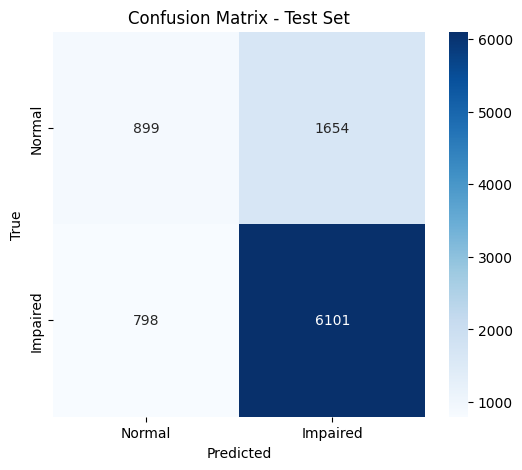

In [87]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import torch

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print("Class weights:", class_weights.numpy())

from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

batch_size = 32

y_train_bin = torch.tensor(y_train >= 1, dtype=torch.long)
y_val_bin = torch.tensor(y_val >= 1, dtype=torch.long)
y_test_bin = torch.tensor(y_test >= 1, dtype=torch.long)

class_sample_count = np.array([len(np.where(y_train_bin == t)[0]) for t in np.unique(y_train_bin)])
weight = 1. / class_sample_count
samples_weight = torch.from_numpy(np.array([weight[t] for t in y_train_bin])).double()
sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

print("Train class counts:", torch.bincount(y_train_bin))
print("Val class counts:", torch.bincount(y_val_bin))
print("Test class counts:", torch.bincount(y_test_bin))

train_dataset = TensorDataset(X_train_t, y_train_bin)
val_dataset = TensorDataset(X_val_t, y_val_bin)
test_dataset = TensorDataset(X_test_t, y_test_bin)

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = EEGTransformer(
    in_channels=19,
    emb_dim=32,
    num_heads=8,
    hidden_dim=64,
    num_layers=1,
    num_classes=2,
    dropout=0.5
).to(device)

criterion = FocalLoss(alpha=0.8, gamma=3.0) # Aggressive focus on the minority class
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=5e-2) # Lower LR for stability
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

num_epochs = 50
patience = 10
best_val_loss = float('inf')
best_epoch = 0
counter = 0

train_losses = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        batch_x = augment_eeg(batch_x)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
    train_loss /= len(train_loader.dataset)
    
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
            _, pred = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (pred == batch_y).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc = 100 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        counter = 0 
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  -> New best model saved")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
    scheduler.step(val_loss)
    
print(f"\nTraining finished. Best Validation loss at epoch {best_epoch+1}: {best_val_loss:.4f}")

model.load_state_dict(torch.load('best_model.pth'))
model.eval()
test_loss = 0.0
test_correct = 0
test_total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item() * batch_x.size(0)
        _, pred = torch.max(outputs, 1)
        test_total += batch_y.size(0)
        test_correct += (pred == batch_y).sum().item()
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())
        
test_loss /= len(test_loader.dataset)
test_acc = 100 * test_correct / test_total

print("\n========== FINAL TEST RESULTS ==========")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

target_names = ['Normal', 'Impaired']
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names))


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test Set')
plt.savefig('confusion_matrix.png')
plt.show()
